In [1]:
! pip install numpy
! pip install matplotlib
! pip install pandas
! pip install scipy
! pip install statsmodels
! pip install seaborn
! pip install tqdm


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# Study 2 Analysis

Implements the preregistered analysis for Study 2 (AsPredicted #286,030, registered 2026-04-19) plus exploratory analyses.

**Design.** 2 × 2: Schema vs. Non-Schema × type of round-4 environmental change (schema-non-obvious vs. schema-obvious).

| Prereg name | Code variable | Treatment string |
|---|---|---|
| Schema × schema-non-obvious | `schema` / `ambiguous` | `schema` |
| Non-Schema × schema-non-obvious | `nonschema` / `ambiguous` | `nonschema` |
| Schema × schema-obvious | `schema` / `incompatible` | `schema_tangrams` |
| Non-Schema × schema-obvious | `nonschema` / `incompatible` | `nonschema_tangrams` |

In this notebook the variable names `ambiguous` and `incompatible` correspond to the prereg's `schema-non-obvious` and `schema-obvious`, respectively.

**Preregistered hypothesis (H1).** Within the Schema condition, groups are more likely to *use a schema* in R4 under schema-non-obvious than under schema-obvious change. Tested with a one-tailed Fisher's exact test on the binarized schema-use DV (a group is coded as using a schema in a round if all members used schema-based names for > half of the 8 images). Schema-use coding is done by three independent human coders, majority vote.

**Exclusions (prereg item 6).** Drop groups where (1) any participant is reported as not participating in Discussion within 60 s or reported more than once; (2) any participant leaves more than two recall responses blank in any single round; (3) video/text review reveals cheating.

**Exploratory analyses (not preregistered).** Earlier drafts of the prereg included accuracy-based interaction contrasts and Mann–Whitney tests within the Schema arm; these were dropped from the final filing in favor of the simpler Fisher's exact test on schema use. They are retained below as exploratory.

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
from scipy import stats
import seaborn as sns

np.random.seed(42)

In [3]:
# [load-data]
# Load Study 2 science data, parse into a participant-level DataFrame.

filenames = sorted(glob.glob("../data/study*2/batch_*.scienceData.jsonl"))
print("Filenames to process:", filenames)

raw = []
for filename in filenames:
    with open(filename) as f:
        for line in f:
            parsed = json.loads(line)
            if parsed["sampleId"] != "missing":
                raw.append(parsed)

print(f"Loaded {len(raw)} participant records")

all_data = pd.DataFrame()
all_data["treatment"] = [row["treatment"]["name"] for row in raw]
all_data["treatmentGroup"] = [row["treatment"]["name"].split("_")[0] for row in raw]      # "schema" / "nonschema"
all_data["changeType"] = ["incompatible" if "tangrams" in row["treatment"]["name"] else "ambiguous" for row in raw]
all_data["sampleId"] = [row["sampleId"] for row in raw]
all_data["gameId"] = [row["gameId"][-6:] for row in raw]
all_data["gameId_full"] = [row["gameId"] for row in raw]
all_data["position"] = [row["position"] for row in raw]

# sanity check: truncated gameId is unique in this dataset
_gameid_collisions = all_data.groupby("gameId")["gameId_full"].nunique()
assert _gameid_collisions.max() == 1, f"Truncated gameId collision(s): {_gameid_collisions[_gameid_collisions > 1].index.tolist()}"

# parse connection / browser / QC info
connection_info = pd.DataFrame([row["connectionInfo"] for row in raw])
all_data = pd.concat([all_data, connection_info], axis=1)
browser_info = pd.DataFrame([row["browserInfo"] for row in raw])
all_data = pd.concat([all_data, browser_info], axis=1)
QC = pd.DataFrame([(row["QCSurvey"]["responses"] if row["QCSurvey"] != "missing" else {}) for row in raw])
all_data = pd.concat([all_data, QC], axis=1)
all_data["num_reports"] = [len(row["reports"]) for row in raw]

# parse labeling submission times (used as a proxy for labeling time)
submit_times = pd.DataFrame([{k: v["time"] for k, v in row["stageSubmissions"].items()} for row in raw])
columns = ["time_" + "_".join(col.replace("submitButton_", "").split("_")[-3:]) for col in submit_times.columns]
submit_times.columns = columns
submit_times = submit_times[sorted(submit_times.columns)]
labeling_times = [col for col in submit_times.columns if "labeling" in col]
submit_times[labeling_times] = submit_times[labeling_times].fillna(300)  # 5-min timeout
assert submit_times[labeling_times].isna().sum().sum() == 0
all_data = pd.concat([all_data, submit_times[labeling_times]], axis=1)

# parse labeling text (raw label-string per round)
label_keys = ["prompt_labeling_1a", "prompt_labeling_1b", "prompt_labeling_1c",
              "prompt_labeling_2", "prompt_labeling_3", "prompt_labeling_4"]
def get_labels(row):
    out = {}
    for key in label_keys:
        try:
            out[key.replace("prompt_", "")] = row["prompts"][key]["value"].strip()
        except (KeyError, TypeError, AttributeError):
            out[key.replace("prompt_", "")] = None
    return out
labels = pd.DataFrame([get_labels(row) for row in raw])
all_data = pd.concat([all_data, labels], axis=1)

# parse recall responses
recall = pd.DataFrame([
    {key: d["value"].lower().strip() for key, d in row["prompts"].items() if "recall" in key}
    for row in raw
])
recall.columns = [col.replace("prompt_recall_", "recall_") for col in recall.columns]
recall = recall[sorted(recall.columns)].fillna("")
expected_recall_counts = {"1a": 2, "1b": 4, "1c": 8, "2": 8, "3": 8, "4": 8}
observed_rounds = {col.split("_")[1] for col in recall.columns}
assert observed_rounds == set(expected_recall_counts), f"Unexpected recall rounds: {observed_rounds}"
observed_recall_counts = {r: sum(col.split("_")[1] == r for col in recall.columns) for r in expected_recall_counts}
assert observed_recall_counts == expected_recall_counts, f"Recall column mismatch: {observed_recall_counts}"
all_data = pd.concat([all_data, recall], axis=1)

# Per-image match: both partners present AND identical response
matches = (
    (all_data.groupby("gameId")[recall.columns].nunique() == 1)
    & (all_data.groupby("gameId")[recall.columns].count() == 2)
)
matches.columns = [col.replace("recall_", "match_") for col in matches.columns]
all_data = pd.merge(left=all_data, right=matches, left_on="gameId", right_index=True)

# Apply mask: matched_recall_X is the recall value if matched, else empty string
for match_col in [c for c in all_data.columns if c.startswith("match_")]:
    recall_col = match_col.replace("match_", "recall_")
    matched_col = match_col.replace("match_", "matched_recall_")
    all_data[matched_col] = all_data[recall_col] * all_data[match_col]

# Accuracy = number of UNIQUE matched labels per round (0-8)
for r in ["1a", "1b", "1c", "2", "3", "4"]:
    cols = [c for c in all_data.columns if f"matched_recall_{r}_" in c]
    all_data[f"accuracy_{r}"] = all_data[cols].replace("", np.nan).nunique(axis=1).astype(float)

print("\nInitial counts by treatment:")
print(all_data.groupby("treatment")["sampleId"].count())

Filenames to process: ['../data/study2/batch_20260513_1556_study2.scienceData.jsonl', '../data/study2/batch_20260514_1509_study2.scienceData.jsonl', '../data/study2/batch_20260514_1804_study2.scienceData.jsonl', '../data/study2/batch_20260514_2044_study2.scienceData.jsonl', '../data/study2/batch_20260518_1749_study2.scienceData.jsonl', '../data/study2/batch_20260518_2112_study2.scienceData.jsonl', '../data/study2/batch_20260520_1249_study2.scienceData.jsonl', '../data/study_2/batch_20260507_1531_study2.scienceData.jsonl']
Loaded 334 participant records

Initial counts by treatment:
treatment
nonschema             80
nonschema_tangrams    82
schema                86
schema_tangrams       86
Name: sampleId, dtype: int64


/var/folders/2l/3kmvzs0s1sggnw_9sl0ls8080000gn/T/ipykernel_6427/655252627.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  QC[field].replace("NA", np.nan).dropna().astype(float).value_counts().sort_index().plot(


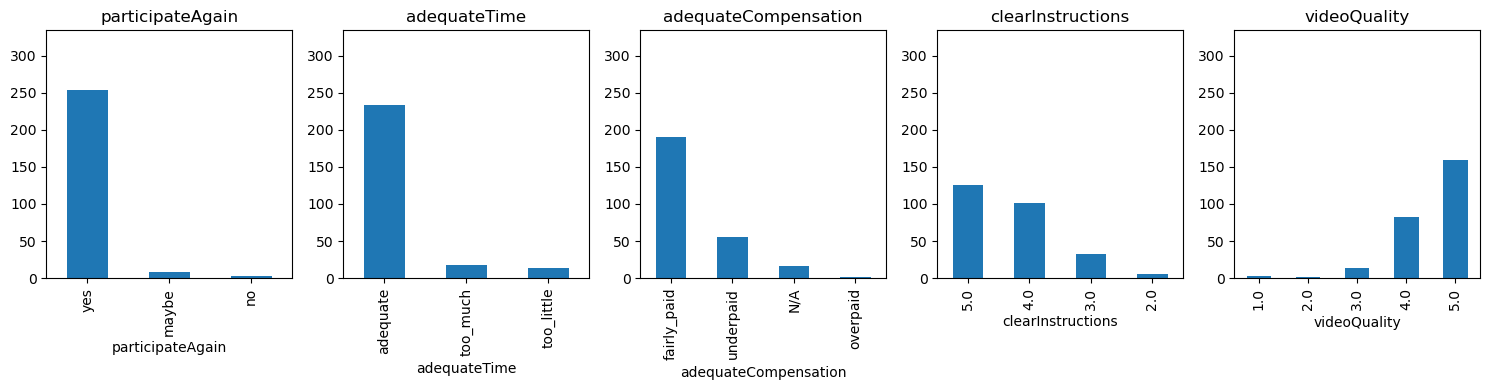

In [4]:
# [plot-qc]
# Sanity check: QC responses across the sample
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
qc_fields = ["participateAgain", "adequateTime", "adequateCompensation", "clearInstructions", "videoQuality"]
for ax, field in zip(axes, qc_fields):
    if field in QC.columns:
        if field == "videoQuality":
            QC[field].replace("NA", np.nan).dropna().astype(float).value_counts().sort_index().plot(
                kind="bar", ax=ax, title=field
            )
        else:
            QC[field].value_counts().plot(kind="bar", ax=ax, title=field)
        ax.set_ylim(0, len(QC))
plt.tight_layout()
plt.show()

In [5]:
# [exclusions]
# Apply preregistered exclusions (item 6 of prereg).
# We exclude groups where:
#   1) any participant non-participation in Discussion Stage (num_reports >= 3 = >1 report)
#   2) any participant drops out before all rounds complete (missing recall)
#   3) [reviewed manually for cheating — flag IDs here as needed]

# Manual flags from video / open-response review (none yet — populate as needed).
flagged_groups = [
    # "XXXXXX",  # reason
]
n_before = all_data["gameId"].nunique()
all_data = all_data[~all_data["gameId"].isin(flagged_groups)]
print(f"After manual flags: {all_data['gameId'].nunique()} groups (was {n_before})")

# (1) Drop participants reported as not participating
all_data = all_data[all_data["num_reports"] < 3]
print(f"After participation filter: {all_data['gameId'].nunique()} groups, {len(all_data)} participants")

# (2) Drop participants who left too many recall responses blank
# Prereg: a group is excluded if either participant leaves more than 2 recall responses
# blank in any single round. Recall rounds 2, 3, 4 each have 8 items.
recall_round_cols = {
    r: [c for c in recall.columns if c.startswith(f"recall_{r}_")] for r in ["1a", "1b", "1c", "2", "3", "4"]
}
def too_many_blanks(participant_row):
    for r, cols in recall_round_cols.items():
        if r in ("1a", "1b"):  # earlier rounds have <8 items, skip the >2 rule
            continue
        n_blank = sum(participant_row[c] == "" for c in cols if c in participant_row)
        if n_blank > 2:
            return True
    return False

mask_blank = all_data.apply(too_many_blanks, axis=1)
print(f"  participants with >2 blanks in any round: {mask_blank.sum()}")
bad_games = all_data.loc[mask_blank, "gameId"].unique()
all_data = all_data[~all_data["gameId"].isin(bad_games)]
print(f"After recall-blank filter: {all_data['gameId'].nunique()} groups, {len(all_data)} participants")

# Keep only complete pairs (both participants have all R3 + R4 data)
pair_complete = (
    all_data.groupby("gameId")[["accuracy_3", "accuracy_4"]].count() == 2
).all(axis=1)
all_data = all_data[all_data["gameId"].isin(pair_complete[pair_complete].index)]
print(f"After complete-pairs filter: {all_data['gameId'].nunique()} groups, {len(all_data)} participants")

# Sanity: no mixed treatments within a gameId
treatment_counts = all_data.groupby("gameId")["treatment"].nunique()
assert treatment_counts.max() == 1, "Mixed treatments within a gameId"

print("\nFinal counts by treatment:")
print(all_data.groupby("treatment")["sampleId"].count())

After manual flags: 167 groups (was 167)
After participation filter: 166 groups, 318 participants
  participants with >2 blanks in any round: 33
After recall-blank filter: 140 groups, 279 participants
After complete-pairs filter: 139 groups, 278 participants

Final counts by treatment:
treatment
nonschema             70
nonschema_tangrams    70
schema                70
schema_tangrams       68
Name: sampleId, dtype: int64


In [6]:
# [aggregate-to-groups]
# Collapse to one row per group (accuracy is identical within a group; labeling time = max).
acc_cols = [c for c in all_data.columns if c.startswith("accuracy_")]
time_cols = [c for c in all_data.columns if c.startswith("time_labeling_")]

# Verify accuracy is identical within each (treatment, gameId)
assert all_data.groupby(["treatment", "gameId"])[acc_cols].std().max().max() == 0

data = (
    all_data.groupby(["treatment", "treatmentGroup", "changeType", "gameId"], as_index=False)
    [acc_cols + time_cols].max()
)
print(f"Group-level dataset: {len(data)} groups")
print()
print("Cell counts:")
print(data.groupby(["treatmentGroup", "changeType"])["gameId"].count())
print()
print("Mean R4 accuracy by cell:")
print(data.groupby(["treatmentGroup", "changeType"])["accuracy_4"].mean().round(2))

Group-level dataset: 139 groups

Cell counts:
treatmentGroup  changeType  
nonschema       ambiguous       35
                incompatible    35
schema          ambiguous       35
                incompatible    34
Name: gameId, dtype: int64

Mean R4 accuracy by cell:
treatmentGroup  changeType  
nonschema       ambiguous       7.23
                incompatible    6.11
schema          ambiguous       5.83
                incompatible    5.18
Name: accuracy_4, dtype: float64


# Preregistered analysis (H1)

One-tailed Fisher's exact test on the proportion of Schema-condition groups that *use a schema* in R4, comparing schema-non-obvious vs. schema-obvious change.

**Required input.** Per-group binary indicator `schema_use_4` (1 if all members used schema-based names for > 4 of the 8 R4 images, 0 otherwise), derived from human coding of R4 recall labels. Three independent coders, majority vote per image.

Schema-use coding is performed outside this notebook; load it from `data/study_2/schema_use_coding.csv` with columns `gameId, schema_use_4` (1/0). If the file is missing, the analysis below prints a placeholder and skips.

In [7]:
# [prereg-h1-fishers-exact]
# Preregistered primary analysis: one-tailed Fisher's exact test on R4 schema use,
# Schema × non-obvious vs Schema × obvious.
import os
from scipy.stats import fisher_exact

coding_path = "../data/study_2/schema_use_coding.csv"

if not os.path.exists(coding_path):
    print(f"[STUB] No schema-use coding found at {coding_path}.")
    print("       Once three coders have labeled R4 schema use per group, save a CSV with")
    print("       columns `gameId, schema_use_4` (1 if >4/8 images used schema-based names")
    print("       per the prereg majority-vote rule, else 0) and re-run this cell.")
else:
    coding = pd.read_csv(coding_path)
    assert set(coding.columns) >= {"gameId", "schema_use_4"}, "coding CSV needs gameId, schema_use_4"
    # Merge onto the group-level dataset
    schema_groups = data[data["treatmentGroup"] == "schema"].merge(
        coding[["gameId", "schema_use_4"]], on="gameId", how="left"
    )
    missing = schema_groups["schema_use_4"].isna().sum()
    if missing > 0:
        print(f"WARNING: {missing} Schema-condition groups missing schema-use coding")
        schema_groups = schema_groups.dropna(subset=["schema_use_4"])

    non_obvious = schema_groups[schema_groups["changeType"] == "ambiguous"]["schema_use_4"].astype(int)
    obvious     = schema_groups[schema_groups["changeType"] == "incompatible"]["schema_use_4"].astype(int)

    a, b = non_obvious.sum(), len(non_obvious) - non_obvious.sum()
    c, d = obvious.sum(),     len(obvious)     - obvious.sum()
    table = np.array([[a, b], [c, d]])

    print("R4 schema use (Schema condition only)")
    print("=" * 60)
    print(f"                              used schema  did not")
    print(f"  schema-non-obvious    {a:>10d} {b:>10d}  (n={len(non_obvious)})")
    print(f"  schema-obvious        {c:>10d} {d:>10d}  (n={len(obvious)})")

    odds_ratio, p_fisher = fisher_exact(table, alternative="greater")
    print(f"\nFisher's exact (one-tailed, non-obvious > obvious):")
    print(f"  odds ratio = {odds_ratio:.3f}")
    print(f"  p          = {p_fisher:.4f}")
    print(f"\n  Decision rule: reject H0 if p < 0.05")

[STUB] No schema-use coding found at ../data/study_2/schema_use_coding.csv.
       Once three coders have labeled R4 schema use per group, save a CSV with
       columns `gameId, schema_use_4` (1 if >4/8 images used schema-based names
       per the prereg majority-vote rule, else 0) and re-run this cell.


## Export labels for human coding

Per prereg item 3, schema-use coding is performed on **recall-stage** labels, not the
discussion-stage labels. This cell exports R4 recall labels in a long-form CSV ready
for three independent coders (one column per coder; aggregate via majority vote per
the prereg).

Each row = one (participant, image) judgement. For each row, the coder marks whether
the participant's R4 recall label for that image is schema-based. Context columns
show the same participant's earlier recall labels (R1c, R2, R3) and the partner's
R3 labels, so the coder can infer the schema the group adopted.

Only Schema-condition groups are exported (the prereg H1 test only requires coding
within the Schema arm). To extend to Non-Schema for descriptive purposes, drop the
`treatmentGroup == "schema"` filter.

In [8]:
# [export-labels-for-coding]
# Build long-form coding sheet from participant-level recall responses.
#
# Output: one row per (gameId, position, image_index) for R4 in Schema-condition groups.
# Fields:
#   - identifiers and condition
#   - label_r4_self / label_r4_partner   (the labels to be considered)
#   - context_r1c_self / r2_self / r3_self  (this participant's prior recall labels)
#   - context_r3_partner                  (partner's R3 recall labels)
#   - three blank coder columns + a notes column

recall_round_sizes = {"1a": 2, "1b": 4, "1c": 8, "2": 8, "3": 8, "4": 8}
recall_cols_by_round = {
    r: [f"recall_{r}_{i}" for i in range(n)] for r, n in recall_round_sizes.items()
}

# Participant-level recall lookup: gameId -> position -> round -> [labels]
participant_recalls = {}
participant_meta = {}
for _, row in all_data[all_data["treatmentGroup"] == "schema"].iterrows():
    gid = row["gameId"]
    pos = row["position"]
    participant_recalls.setdefault(gid, {})[pos] = {
        r: [row.get(col, "") for col in cols] for r, cols in recall_cols_by_round.items()
    }
    participant_meta.setdefault(gid, {
        "treatment": row["treatment"],
        "changeType": row["changeType"],
    })

coding_rows = []
for gid, parts in participant_recalls.items():
    positions = sorted(parts.keys())
    if len(positions) != 2:
        continue  # only complete pairs
    meta = participant_meta[gid]
    for self_pos in positions:
        partner_pos = [p for p in positions if p != self_pos][0]
        self_recalls = parts[self_pos]
        partner_recalls = parts[partner_pos]
        for i in range(8):
            coding_rows.append({
                "gameId": gid,
                "treatment": meta["treatment"],
                "changeType": meta["changeType"],
                "position": self_pos,
                "image_index": i,
                "label_r4_self": self_recalls["4"][i],
                "label_r4_partner": partner_recalls["4"][i],
                "context_r1c_self": "; ".join(self_recalls["1c"]),
                "context_r2_self":  "; ".join(self_recalls["2"]),
                "context_r3_self":  "; ".join(self_recalls["3"]),
                "context_r3_partner": "; ".join(partner_recalls["3"]),
                "coder_1_schema_based": "",
                "coder_2_schema_based": "",
                "coder_3_schema_based": "",
                "notes": "",
            })

coding_df = pd.DataFrame(coding_rows).sort_values(["gameId", "position", "image_index"]).reset_index(drop=True)

print(f"Exported {len(coding_df)} rows for coding")
print(f"  Schema-condition groups: {coding_df['gameId'].nunique()}")
print(f"  Rows per group: {coding_df.groupby('gameId').size().unique()}")
print(f"  Treatments: {coding_df.groupby(['treatment', 'changeType']).size().to_dict()}")

out_path = "../data/study_2/r4_labels_for_coding.csv"
coding_df.to_csv(out_path, index=False)
print(f"\nWrote to {out_path}")

# Preview
coding_df.head(3)

Exported 1104 rows for coding
  Schema-condition groups: 69
  Rows per group: [16]
  Treatments: {('schema', 'ambiguous'): 560, ('schema_tangrams', 'incompatible'): 544}

Wrote to ../data/study_2/r4_labels_for_coding.csv


,gameId,treatment,changeType,position,image_index,label_r4_self,label_r4_partner,context_r1c_self,context_r2_self,context_r3_self,context_r3_partner,coder_1_schema_based,coder_2_schema_based,coder_3_schema_based,notes
0,0ES8D4,schema,ambiguous,0,0,purple hat right yellow feet tall,purple hat right yellow feet tall,purple hat right brown feet; orange hat right ...,purple hat left brown feet; orange hat left ye...,orange hat right yellow feet; orange hat left ...,orange hat right yellow feet; orange hat left ...,,,,
1,0ES8D4,schema,ambiguous,0,1,purple hat right yellow feet short,purple hat right yellow feet short,purple hat right brown feet; orange hat right ...,purple hat left brown feet; orange hat left ye...,orange hat right yellow feet; orange hat left ...,orange hat right yellow feet; orange hat left ...,,,,
2,0ES8D4,schema,ambiguous,0,2,orange hat left brown feet tall,orange hat right brown feet tall,purple hat right brown feet; orange hat right ...,purple hat left brown feet; orange hat left ye...,orange hat right yellow feet; orange hat left ...,orange hat right yellow feet; orange hat left ...,,,,


## Export R4 labels for crowdworker coding (Stagebook annotator workflow)

The cell above writes a flat CSV for offline coding. The cell below generates the per-task stimulus markdown files for the Stagebook annotator workflow at `stagebook/annotation/r4_label_coding/`, plus a tasks-index CSV that maps each (gameId, position) to the prompt files it needs.

Each task = one participant's eight Round 4 labels. The annotator sees that participant's R1c–R3 recall labels and the partner's R3 labels for context, then classifies each R4 label into one of {Holistic name, Schema, Arbitrary label, No response, Unknown}.

Both Schema and Non-Schema groups are exported. R4 only for now (R3 may be added later by extending the cell). Replication count and which subset to actually send to crowdworkers are handled at the annotator-project setup level, not in this workflow.

In [9]:
# [export-r4-label-coding-stimuli]
# Generate per-task stimulus prompt files for the stagebook workflow at
# stagebook/annotation/r4_label_coding/.
# Per task (one row per gameId x position): 9 files
#   - {gameId}_p{position}.context.prompt.md       (4-column round-by-round table)
#   - {gameId}_p{position}.label_{1..8}.prompt.md  (each shows one R4 label)
# Plus a tasks-index CSV that lists the contextFile and labelFile1..labelFile8
# for each task, ready to feed into the annotator project as task fields.

import os
import shutil

stimuli_dir = "../stagebook/annotation/r4_label_coding/stimuli"
tasks_csv_path = "../data/study_2/r4_label_coding_tasks.csv"

# Wipe previously generated stimuli so we never leave orphans behind
if os.path.exists(stimuli_dir):
    shutil.rmtree(stimuli_dir)
os.makedirs(stimuli_dir, exist_ok=True)

# Pull recall labels (in image_index order) per (gameId, position, round)
recall_round_sizes = {"1c": 8, "2": 8, "3": 8, "4": 8}
recall_cols_by_round = {
    r: [f"recall_{r}_{i}" for i in range(n)] for r, n in recall_round_sizes.items()
}

participant_recalls = {}
participant_meta = {}
for _, row in all_data.iterrows():
    gid = row["gameId"]
    pos = int(row["position"])
    participant_recalls.setdefault(gid, {})[pos] = {
        r: [row.get(col, "") for col in cols] for r, cols in recall_cols_by_round.items()
    }
    participant_meta.setdefault(gid, {
        "treatment": row["treatment"],
        "treatmentGroup": row["treatmentGroup"],
        "changeType": row["changeType"],
    })


def fmt_cell(lbl):
    """Render a single label cell for the markdown table."""
    s = "" if lbl is None else str(lbl).strip()
    return "∅" if s == "" else s


def write_file(path, lines):
    with open(path, "w") as f:
        f.write("\n".join(lines).rstrip() + "\n")


task_rows = []
for gid in sorted(participant_recalls.keys()):
    positions = sorted(participant_recalls[gid].keys())
    if len(positions) != 2:
        continue  # only complete pairs

    meta = participant_meta[gid]
    for self_pos in positions:
        self_recalls = participant_recalls[gid][self_pos]

        # --- Context file: 4-column table with this participant's labels
        # Note: stored data column "1c" is displayed as "Round 1" for annotators
        ctx = [
            "---",
            "type: noResponse",
            "---",
            "",
            "### Classify labels from this participant's **round 4** using the above categories.",
            "",
            "Each round uses a different image set, and labels may vary across rounds.",
            "",
            "∅ = no response.",
            "",
            "| #   | Round 1 | Round 2 | Round 3 | **Round 4** |",
            "| --- | ------- | ------- | ------- | ----------- |",
        ]
        for i in range(8):
            r1 = fmt_cell(self_recalls["1c"][i])
            r2 = fmt_cell(self_recalls["2"][i])
            r3 = fmt_cell(self_recalls["3"][i])
            r4 = fmt_cell(self_recalls["4"][i])
            ctx.append(f"| {i+1}   | {r1} | {r2} | {r3} | **{r4}** |")

        ctx_filename = f"{gid}_p{self_pos}.context.prompt.md"
        write_file(os.path.join(stimuli_dir, ctx_filename), ctx)

        # --- One per-label file per R4 label (unchanged structure)
        r4_labels = self_recalls["4"]
        label_files = []
        for i, lbl in enumerate(r4_labels, start=1):
            s = "" if lbl is None else str(lbl).strip()
            display = "∅ (no response)" if s == "" else s
            lf_lines = [
                "---",
                "type: noResponse",
                "---",
                "",
                f"### Label {i}",
                "",
                f"> {display}",
                "",
            ]
            lf_filename = f"{gid}_p{self_pos}.label_{i}.prompt.md"
            write_file(os.path.join(stimuli_dir, lf_filename), lf_lines)
            label_files.append(f"stimuli/{lf_filename}")

        task_row = {
            "gameId": gid,
            "position": self_pos,
            "treatment": meta["treatment"],
            "treatmentGroup": meta["treatmentGroup"],
            "changeType": meta["changeType"],
            "contextFile": f"stimuli/{ctx_filename}",
        }
        for i, lf in enumerate(label_files, start=1):
            task_row[f"labelFile{i}"] = lf
        task_rows.append(task_row)

tasks_df = pd.DataFrame(task_rows)
os.makedirs(os.path.dirname(tasks_csv_path), exist_ok=True)
tasks_df.to_csv(tasks_csv_path, index=False)

print(f"Wrote {len(task_rows)} tasks ({len(task_rows) * 9} stimulus files) to {stimuli_dir}/")
print(f"Wrote tasks index to {tasks_csv_path}")
print("\nTasks per (treatmentGroup, changeType):")
print(tasks_df.groupby(["treatmentGroup", "changeType"]).size())
tasks_df.head(3)


Wrote 278 tasks (2502 stimulus files) to ../stagebook/annotation/r4_label_coding/stimuli/
Wrote tasks index to ../data/study_2/r4_label_coding_tasks.csv

Tasks per (treatmentGroup, changeType):
treatmentGroup  changeType  
nonschema       ambiguous       70
                incompatible    70
schema          ambiguous       70
                incompatible    68
dtype: int64


,gameId,position,treatment,treatmentGroup,changeType,contextFile,labelFile1,labelFile2,labelFile3,labelFile4,labelFile5,labelFile6,labelFile7,labelFile8
0,0E3FH7,0,nonschema,nonschema,ambiguous,stimuli/0E3FH7_p0.context.prompt.md,stimuli/0E3FH7_p0.label_1.prompt.md,stimuli/0E3FH7_p0.label_2.prompt.md,stimuli/0E3FH7_p0.label_3.prompt.md,stimuli/0E3FH7_p0.label_4.prompt.md,stimuli/0E3FH7_p0.label_5.prompt.md,stimuli/0E3FH7_p0.label_6.prompt.md,stimuli/0E3FH7_p0.label_7.prompt.md,stimuli/0E3FH7_p0.label_8.prompt.md
1,0E3FH7,1,nonschema,nonschema,ambiguous,stimuli/0E3FH7_p1.context.prompt.md,stimuli/0E3FH7_p1.label_1.prompt.md,stimuli/0E3FH7_p1.label_2.prompt.md,stimuli/0E3FH7_p1.label_3.prompt.md,stimuli/0E3FH7_p1.label_4.prompt.md,stimuli/0E3FH7_p1.label_5.prompt.md,stimuli/0E3FH7_p1.label_6.prompt.md,stimuli/0E3FH7_p1.label_7.prompt.md,stimuli/0E3FH7_p1.label_8.prompt.md
2,0ES8D4,0,schema,schema,ambiguous,stimuli/0ES8D4_p0.context.prompt.md,stimuli/0ES8D4_p0.label_1.prompt.md,stimuli/0ES8D4_p0.label_2.prompt.md,stimuli/0ES8D4_p0.label_3.prompt.md,stimuli/0ES8D4_p0.label_4.prompt.md,stimuli/0ES8D4_p0.label_5.prompt.md,stimuli/0ES8D4_p0.label_6.prompt.md,stimuli/0ES8D4_p0.label_7.prompt.md,stimuli/0ES8D4_p0.label_8.prompt.md


# Exploratory analyses (not preregistered)

The analyses below were planned in earlier prereg drafts but dropped from the filed prereg in favor of the simpler Fisher's exact test above. They are kept as exploratory tests on the accuracy DV.

## H1 (exploratory): Interaction contrast on R4 accuracy

`penalty(x) = mean(Schema, x) - mean(Non-Schema, x)`. Test whether
`penalty(ambiguous) - penalty(incompatible) < 0` (one-tailed) using a restricted
permutation test: within each Schema condition, permute change-type labels across
groups, recompute the contrast, repeat 10,000 times.

In [10]:
# [h1-interaction-contrast]
np.random.seed(42)

def get_cell(tg, ct):
    return data[(data["treatmentGroup"] == tg) & (data["changeType"] == ct)]["accuracy_4"].values

schema_amb = get_cell("schema", "ambiguous")
schema_inc = get_cell("schema", "incompatible")
nonschema_amb = get_cell("nonschema", "ambiguous")
nonschema_inc = get_cell("nonschema", "incompatible")

print("Cell sizes:")
print(f"  Schema     × ambiguous:    n={len(schema_amb):3d}  mean={schema_amb.mean():.2f}")
print(f"  Schema     × incompatible: n={len(schema_inc):3d}  mean={schema_inc.mean():.2f}")
print(f"  Non-schema × ambiguous:    n={len(nonschema_amb):3d}  mean={nonschema_amb.mean():.2f}")
print(f"  Non-schema × incompatible: n={len(nonschema_inc):3d}  mean={nonschema_inc.mean():.2f}")

penalty_amb = schema_amb.mean() - nonschema_amb.mean()
penalty_inc = schema_inc.mean() - nonschema_inc.mean()
observed_contrast = penalty_amb - penalty_inc
print(f"\npenalty(ambiguous):    {penalty_amb:+.3f}")
print(f"penalty(incompatible): {penalty_inc:+.3f}")
print(f"interaction contrast:  {observed_contrast:+.3f}")
print(f"  (negative = ambiguous penalty larger, supports H1)")

# Restricted permutation test: within each schema condition, shuffle change-type labels.
def restricted_perm_p(schema_amb, schema_inc, nonschema_amb, nonschema_inc, n_perm=10000, seed=42):
    rng = np.random.default_rng(seed)
    obs = (schema_amb.mean() - nonschema_amb.mean()) - (schema_inc.mean() - nonschema_inc.mean())
    schema_pool = np.concatenate([schema_amb, schema_inc])
    schema_split = len(schema_amb)
    ns_pool = np.concatenate([nonschema_amb, nonschema_inc])
    ns_split = len(nonschema_amb)
    perm_contrasts = np.empty(n_perm)
    for i in range(n_perm):
        sp = rng.permutation(schema_pool)
        np_ = rng.permutation(ns_pool)
        perm_amb_s = sp[:schema_split]
        perm_inc_s = sp[schema_split:]
        perm_amb_n = np_[:ns_split]
        perm_inc_n = np_[ns_split:]
        perm_contrasts[i] = (perm_amb_s.mean() - perm_amb_n.mean()) - (perm_inc_s.mean() - perm_inc_n.mean())
    p = (perm_contrasts <= obs).mean()  # one-tailed: more negative
    return obs, p, perm_contrasts

obs, p_perm, perm_contrasts = restricted_perm_p(schema_amb, schema_inc, nonschema_amb, nonschema_inc)
print(f"\nRestricted permutation test (one-tailed, H1: contrast < 0):")
print(f"  observed contrast = {obs:+.3f}")
print(f"  p (perm, n=10,000) = {p_perm:.4f}")

# Cliff's delta within each change-type arm (Schema vs Non-schema)
def cliffs_delta(x, y):
    if len(x) == 0 or len(y) == 0:
        return np.nan
    n1, n2 = len(x), len(y)
    greater = np.sum(x[:, np.newaxis] > y)
    less = np.sum(x[:, np.newaxis] < y)
    return (greater - less) / (n1 * n2)

cd_amb = cliffs_delta(schema_amb, nonschema_amb)
cd_inc = cliffs_delta(schema_inc, nonschema_inc)
print(f"\nCliff's delta (Schema vs Non-schema, within arm):")
print(f"  ambiguous:    {cd_amb:+.3f}")
print(f"  incompatible: {cd_inc:+.3f}")

Cell sizes:
  Schema     × ambiguous:    n= 35  mean=5.83
  Schema     × incompatible: n= 34  mean=5.18
  Non-schema × ambiguous:    n= 35  mean=7.23
  Non-schema × incompatible: n= 35  mean=6.11

penalty(ambiguous):    -1.400
penalty(incompatible): -0.938
interaction contrast:  -0.462
  (negative = ambiguous penalty larger, supports H1)

Restricted permutation test (one-tailed, H1: contrast < 0):
  observed contrast = -0.462
  p (perm, n=10,000) = 0.2441

Cliff's delta (Schema vs Non-schema, within arm):
  ambiguous:    -0.440
  incompatible: -0.222


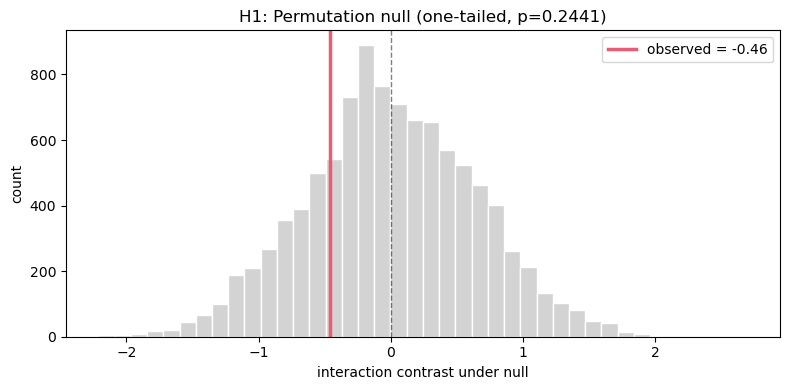

In [11]:
# [h1-plot]
# Plot the permutation null distribution with observed contrast
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm_contrasts, bins=40, color="lightgray", edgecolor="white")
ax.axvline(observed_contrast, color="#E85D75", linewidth=2.5, label=f"observed = {observed_contrast:+.2f}")
ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax.set_xlabel("interaction contrast under null")
ax.set_ylabel("count")
ax.set_title(f"H1: Permutation null (one-tailed, p={p_perm:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

## H1 reframed (exploratory): relative benefit of an unambiguous switch

The accuracy-based H1 contrast above is framed as the *extra penalty* of having a schema
when the R4 change is ambiguous vs. incompatible. The same diff-in-diff can be
reframed as the *relative benefit* to Schema groups of an unambiguous (incompatible)
switch over an ambiguous switch — using the Non-Schema group to control for the
baseline difficulty of the R4 task itself:

- `benefit(Schema) = mean(Schema, inc) - mean(Schema, amb)`
- `benefit(Non-Schema) = mean(Non-Schema, inc) - mean(Non-Schema, amb)`
- `relative_benefit = benefit(Schema) - benefit(Non-Schema)`

Algebraically `relative_benefit = -(H1 contrast)`, so the null distribution and
one-tailed p-value carry over. Predicted direction: **positive** (Schema groups
benefit more from being told the switch is incompatible, because the schema isn't
seductively misleading them).

benefit(Schema):     mean(Schema,inc) - mean(Schema,amb)        = -0.652
benefit(Non-Schema): mean(NS,inc)     - mean(NS,amb)            = -1.114
relative_benefit   = benefit(Schema) - benefit(Non-Schema)      = +0.462
  (positive = Schema groups benefit more from incompatible switch, supports H1)

Restricted permutation test (one-tailed, relative_benefit > 0):
  observed = +0.462
  p (perm, n=10,000) = 0.2441
  (equals H1 p-value: 0.2441)


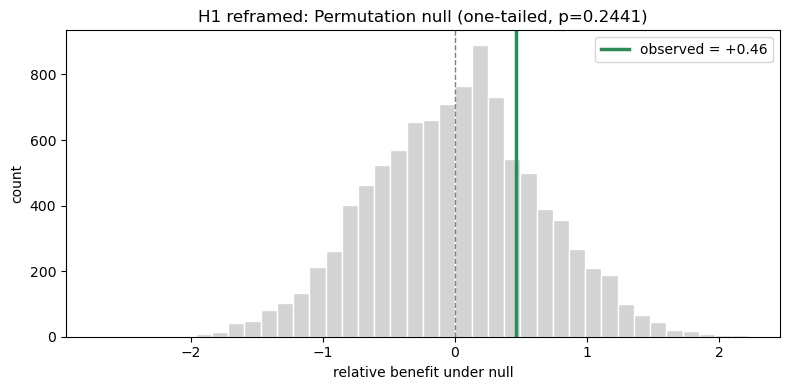

In [12]:
# [h1-reframed-relative-benefit]
benefit_schema = schema_inc.mean() - schema_amb.mean()
benefit_nonschema = nonschema_inc.mean() - nonschema_amb.mean()
relative_benefit_obs = benefit_schema - benefit_nonschema

# Reuse the restricted permutation null from H1 above (sign-flipped)
relative_benefit_null = -perm_contrasts
p_relative_benefit = (relative_benefit_null >= relative_benefit_obs).mean()  # one-tailed: more positive

# Sanity: should equal H1 p-value
assert abs(p_relative_benefit - p_perm) < 1e-9 or abs(relative_benefit_obs + observed_contrast) < 1e-9, \
    "relative benefit should be -contrast"

print(f"benefit(Schema):     mean(Schema,inc) - mean(Schema,amb)        = {benefit_schema:+.3f}")
print(f"benefit(Non-Schema): mean(NS,inc)     - mean(NS,amb)            = {benefit_nonschema:+.3f}")
print(f"relative_benefit   = benefit(Schema) - benefit(Non-Schema)      = {relative_benefit_obs:+.3f}")
print(f"  (positive = Schema groups benefit more from incompatible switch, supports H1)")
print(f"\nRestricted permutation test (one-tailed, relative_benefit > 0):")
print(f"  observed = {relative_benefit_obs:+.3f}")
print(f"  p (perm, n=10,000) = {p_relative_benefit:.4f}")
print(f"  (equals H1 p-value: {p_perm:.4f})")

# Plot null distribution under the new framing
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(relative_benefit_null, bins=40, color="lightgray", edgecolor="white")
ax.axvline(relative_benefit_obs, color="#2E8B57", linewidth=2.5, label=f"observed = {relative_benefit_obs:+.2f}")
ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax.set_xlabel("relative benefit under null")
ax.set_ylabel("count")
ax.set_title(f"H1 reframed: Permutation null (one-tailed, p={p_relative_benefit:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

## H2a (exploratory): Within Schema, R4 accuracy (incompatible > ambiguous)

One-tailed Mann-Whitney U with permutation p-value, plus medians, Hodges-Lehmann
estimate (95% bootstrap CI), and Cliff's delta.

In [13]:
# [h2a-mwu]
np.random.seed(42)

def perm_mwu_p(a, b, alt="greater", n_perm=10000, seed=42):
    """One-sided permutation p-value for Mann-Whitney U.
    For alt="greater": p = fraction of permutations with U >= observed.
    For alt="less":    p = fraction of permutations with U <= observed."""
    rng = np.random.default_rng(seed)
    u_obs, _ = stats.mannwhitneyu(a, b, alternative=alt)
    pool = np.concatenate([a, b])
    split = len(a)
    extreme = 0
    for _ in range(n_perm):
        perm = rng.permutation(pool)
        u_perm, _ = stats.mannwhitneyu(perm[:split], perm[split:], alternative=alt)
        if alt == "greater" and u_perm >= u_obs:
            extreme += 1
        elif alt == "less" and u_perm <= u_obs:
            extreme += 1
    return u_obs, extreme / n_perm

# Mann-Whitney U, alternative="greater" (incompatible > ambiguous)
u_stat, p_asymp = stats.mannwhitneyu(schema_inc, schema_amb, alternative="greater")
u_obs_2a, p_perm_2a = perm_mwu_p(schema_inc, schema_amb, alt="greater")

# Hodges-Lehmann estimate (incompatible - ambiguous)
hl_2a = np.median(schema_inc[:, np.newaxis] - schema_amb)

n_boot = 9999
boot_hl = np.empty(n_boot)
rng_b = np.random.default_rng(42)
for i in range(n_boot):
    bi = rng_b.choice(schema_inc, size=len(schema_inc), replace=True)
    ba = rng_b.choice(schema_amb, size=len(schema_amb), replace=True)
    boot_hl[i] = np.median(bi[:, np.newaxis] - ba)
hl_ci_2a = np.percentile(boot_hl, [2.5, 97.5])

cd_2a = cliffs_delta(schema_inc, schema_amb)

print("=" * 60)
print("H2a: Schema x incompatible vs Schema x ambiguous (R4 accuracy)")
print("=" * 60)
print(f"  Schema x ambiguous:    n={len(schema_amb):3d}  median={np.median(schema_amb):.1f}  mean={schema_amb.mean():.2f}")
print(f"  Schema x incompatible: n={len(schema_inc):3d}  median={np.median(schema_inc):.1f}  mean={schema_inc.mean():.2f}")
print(f"  Mann-Whitney U: U={u_obs_2a:.1f}  p (asymp, one-tailed) = {p_asymp:.4f}")
print(f"                  p (perm, one-tailed)  = {p_perm_2a:.4f}")
print(f"  Hodges-Lehmann (inc - amb): {hl_2a:+.2f}  [95% CI: {hl_ci_2a[0]:+.2f}, {hl_ci_2a[1]:+.2f}]")
print(f"  Cliff\'s delta: {cd_2a:+.3f}")

H2a: Schema x incompatible vs Schema x ambiguous (R4 accuracy)
  Schema x ambiguous:    n= 35  median=6.0  mean=5.83
  Schema x incompatible: n= 34  median=5.5  mean=5.18
  Mann-Whitney U: U=508.0  p (asymp, one-tailed) = 0.8579
                  p (perm, one-tailed)  = 0.8537
  Hodges-Lehmann (inc - amb): +0.00  [95% CI: -2.00, +0.00]
  Cliff's delta: -0.146


## H2b (exploratory): Within Schema, ΔR4-R3 (more negative under ambiguous)

Same nonparametric framework as H2a, applied to the within-group change R4 - R3.
Predicted direction: `delta_amb < delta_inc` (one-tailed).

In [14]:
# [h2b-delta-mwu]
np.random.seed(42)

schema_amb_full = data[(data["treatmentGroup"] == "schema") & (data["changeType"] == "ambiguous")]
schema_inc_full = data[(data["treatmentGroup"] == "schema") & (data["changeType"] == "incompatible")]

delta_amb = (schema_amb_full["accuracy_4"] - schema_amb_full["accuracy_3"]).values
delta_inc = (schema_inc_full["accuracy_4"] - schema_inc_full["accuracy_3"]).values

u_stat_2b, p_asymp_2b = stats.mannwhitneyu(delta_amb, delta_inc, alternative="less")
u_obs_2b, p_perm_2b = perm_mwu_p(delta_amb, delta_inc, alt="less")

hl_2b = np.median(delta_amb[:, np.newaxis] - delta_inc)
boot_hl_2b = np.empty(n_boot)
rng_b = np.random.default_rng(42)
for i in range(n_boot):
    ba = rng_b.choice(delta_amb, size=len(delta_amb), replace=True)
    bi = rng_b.choice(delta_inc, size=len(delta_inc), replace=True)
    boot_hl_2b[i] = np.median(ba[:, np.newaxis] - bi)
hl_ci_2b = np.percentile(boot_hl_2b, [2.5, 97.5])

cd_2b = cliffs_delta(delta_amb, delta_inc)

print("=" * 60)
print("H2b: dR4-R3 within Schema (ambiguous vs incompatible)")
print("=" * 60)
print(f"  Schema x ambiguous:    n={len(delta_amb):3d}  median d={np.median(delta_amb):+.1f}  mean d={delta_amb.mean():+.2f}")
print(f"  Schema x incompatible: n={len(delta_inc):3d}  median d={np.median(delta_inc):+.1f}  mean d={delta_inc.mean():+.2f}")
print(f"  Mann-Whitney U: U={u_obs_2b:.1f}  p (asymp, one-tailed) = {p_asymp_2b:.4f}")
print(f"                  p (perm, one-tailed)  = {p_perm_2b:.4f}")
print(f"  Hodges-Lehmann (amb - inc): {hl_2b:+.2f}  [95% CI: {hl_ci_2b[0]:+.2f}, {hl_ci_2b[1]:+.2f}]")
print(f"  Cliff\'s delta: {cd_2b:+.3f}")

H2b: dR4-R3 within Schema (ambiguous vs incompatible)
  Schema x ambiguous:    n= 35  median d=-1.0  mean d=-1.37
  Schema x incompatible: n= 34  median d=-2.0  mean d=-2.18
  Mann-Whitney U: U=737.5  p (asymp, one-tailed) = 0.9591
                  p (perm, one-tailed)  = 0.9590
  Hodges-Lehmann (amb - inc): +1.00  [95% CI: +0.00, +2.00]
  Cliff's delta: +0.239


## Replication check (exploratory): Study 1 effects in the schema-ambiguous arm

The schema-ambiguous arm uses identical stimuli/procedures to Study 1.
Replication target: Schema underperforms Non-Schema in R4 accuracy.

In [15]:
# [replication-check]
# Compare to Study 1 finding: in schema-ambiguous arm, Schema < Non-schema in R4 accuracy
np.random.seed(42)

u_rep, p_rep_asymp = stats.mannwhitneyu(schema_amb, nonschema_amb, alternative="less")
u_rep_obs, p_rep_perm = perm_mwu_p(schema_amb, nonschema_amb, alt="less")

cd_rep = cliffs_delta(schema_amb, nonschema_amb)
hl_rep = np.median(schema_amb[:, np.newaxis] - nonschema_amb)

print("=" * 60)
print("Replication: schema-ambiguous arm (R4 accuracy, Schema < Non-schema)")
print("=" * 60)
print(f"  Schema:     n={len(schema_amb):3d}  median={np.median(schema_amb):.1f}  mean={schema_amb.mean():.2f}")
print(f"  Non-schema: n={len(nonschema_amb):3d}  median={np.median(nonschema_amb):.1f}  mean={nonschema_amb.mean():.2f}")
print(f"  Mann-Whitney U: U={u_rep_obs:.1f}  p (perm, one-tailed) = {p_rep_perm:.4f}")
print(f"  HL (schema - nonschema): {hl_rep:+.2f}")
print(f"  Cliff's delta: {cd_rep:+.3f}")

Replication: schema-ambiguous arm (R4 accuracy, Schema < Non-schema)
  Schema:     n= 35  median=6.0  mean=5.83
  Non-schema: n= 35  median=8.0  mean=7.23
  Mann-Whitney U: U=343.0  p (perm, one-tailed) = 0.0007
  HL (schema - nonschema): -1.00
  Cliff's delta: -0.440


# Figures

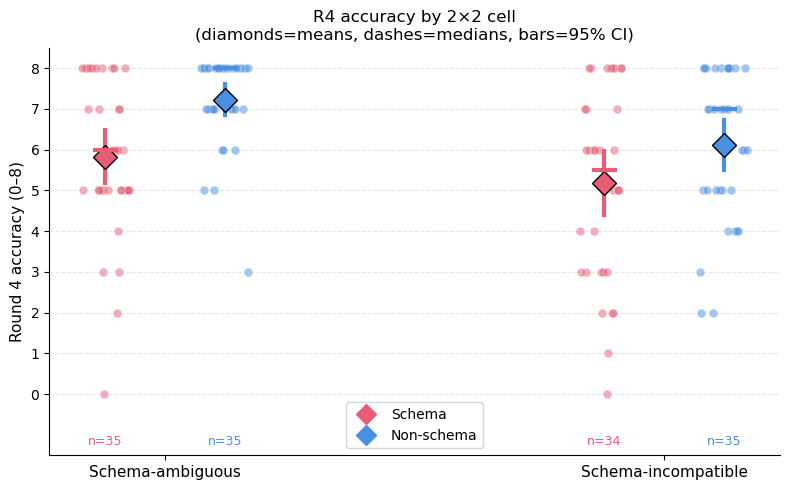

In [16]:
# [fig-cell-means]
# 2x2 cell-means plot for R4 accuracy
fig, ax = plt.subplots(figsize=(8, 5))

cells = {
    ("schema", "ambiguous"): schema_amb,
    ("schema", "incompatible"): schema_inc,
    ("nonschema", "ambiguous"): nonschema_amb,
    ("nonschema", "incompatible"): nonschema_inc,
}

color_map = {"schema": "#E85D75", "nonschema": "#4A90E2"}
xpos = {"ambiguous": 0, "incompatible": 1}
offset = {"schema": -0.12, "nonschema": 0.12}

rng = np.random.default_rng(42)
for (tg, ct), vals in cells.items():
    if len(vals) == 0:
        continue
    x = xpos[ct] + offset[tg]
    jit = rng.uniform(-0.05, 0.05, size=len(vals))
    ax.scatter(np.full(len(vals), x) + jit, vals, color=color_map[tg], alpha=0.5, s=40,
               edgecolors="white", linewidth=0.5)
    ax.plot(x, np.mean(vals), "D", color=color_map[tg], markersize=12,
            markeredgecolor="black", zorder=5)
    ax.plot(x, np.median(vals), "_", color=color_map[tg], markersize=18,
            markeredgewidth=3, zorder=5)
    se = np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0
    ax.plot([x, x], [np.mean(vals) - 1.96*se, np.mean(vals) + 1.96*se],
            color=color_map[tg], linewidth=3, zorder=4)
    # n annotation, just below the x-axis at each marker
    ax.text(x, -1.0, f"n={len(vals)}", ha="center", va="top",
            fontsize=9, color=color_map[tg])

ax.set_ylim(-1.5, 8.5)  # leave room for n labels below
ax.set_xticks([0, 1])
ax.set_xticklabels(["Schema-ambiguous", "Schema-incompatible"], fontsize=11)
ax.set_ylabel("Round 4 accuracy (0–8)", fontsize=11)
ax.set_yticks(range(0, 9))
ax.set_title("R4 accuracy by 2×2 cell\n(diamonds=means, dashes=medians, bars=95% CI)")

# legend
import matplotlib.lines as mlines
legend_elements = [
    mlines.Line2D([], [], color=color_map["schema"], marker="D", linestyle="none",
                  markersize=10, label="Schema"),
    mlines.Line2D([], [], color=color_map["nonschema"], marker="D", linestyle="none",
                  markersize=10, label="Non-schema"),
]
ax.legend(handles=legend_elements, fontsize=10, loc="lower center")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

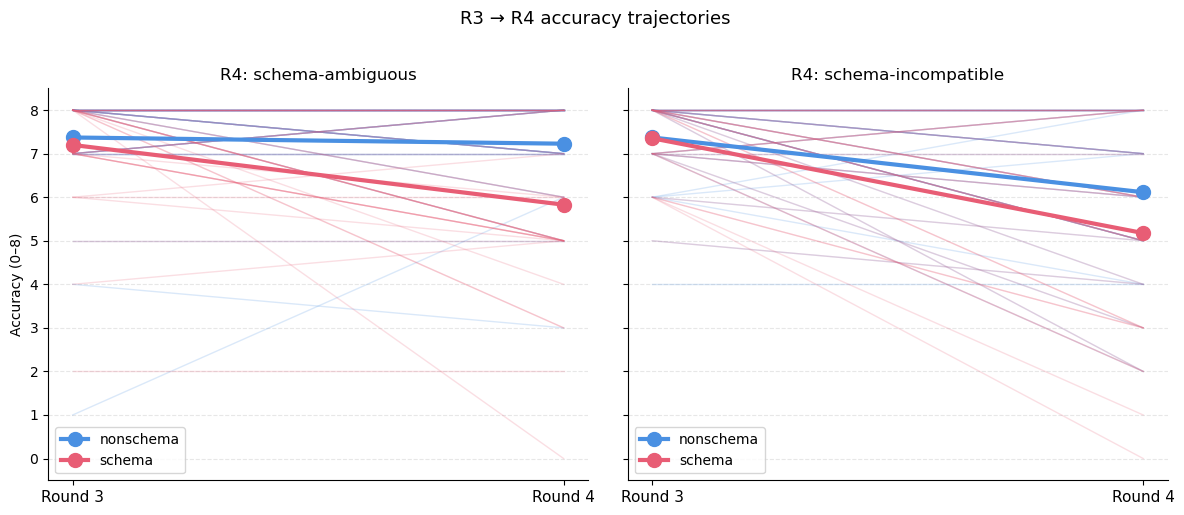

In [17]:
# [fig-r3-r4-trajectories]
# R3 → R4 trajectories within Schema groups, faceted by change type
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
color_map = {"schema": "#E85D75", "nonschema": "#4A90E2"}

for ax, ct in zip(axes, ["ambiguous", "incompatible"]):
    for tg in ["nonschema", "schema"]:
        sub = data[(data["treatmentGroup"] == tg) & (data["changeType"] == ct)]
        for _, row in sub.iterrows():
            ax.plot([0, 1], [row["accuracy_3"], row["accuracy_4"]],
                    color=color_map[tg], alpha=0.2, linewidth=1)
        if len(sub) > 0:
            m3, m4 = sub["accuracy_3"].mean(), sub["accuracy_4"].mean()
            ax.plot([0, 1], [m3, m4], color=color_map[tg], linewidth=3,
                    marker="o", markersize=10, label=tg, zorder=5)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Round 3", "Round 4"], fontsize=11)
    ax.set_ylabel("Accuracy (0–8)" if ct == "ambiguous" else "")
    ax.set_ylim(-0.5, 8.5)
    ax.set_yticks(range(0, 9))
    ax.set_title(f"R4: schema-{ct}", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("R3 → R4 accuracy trajectories", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

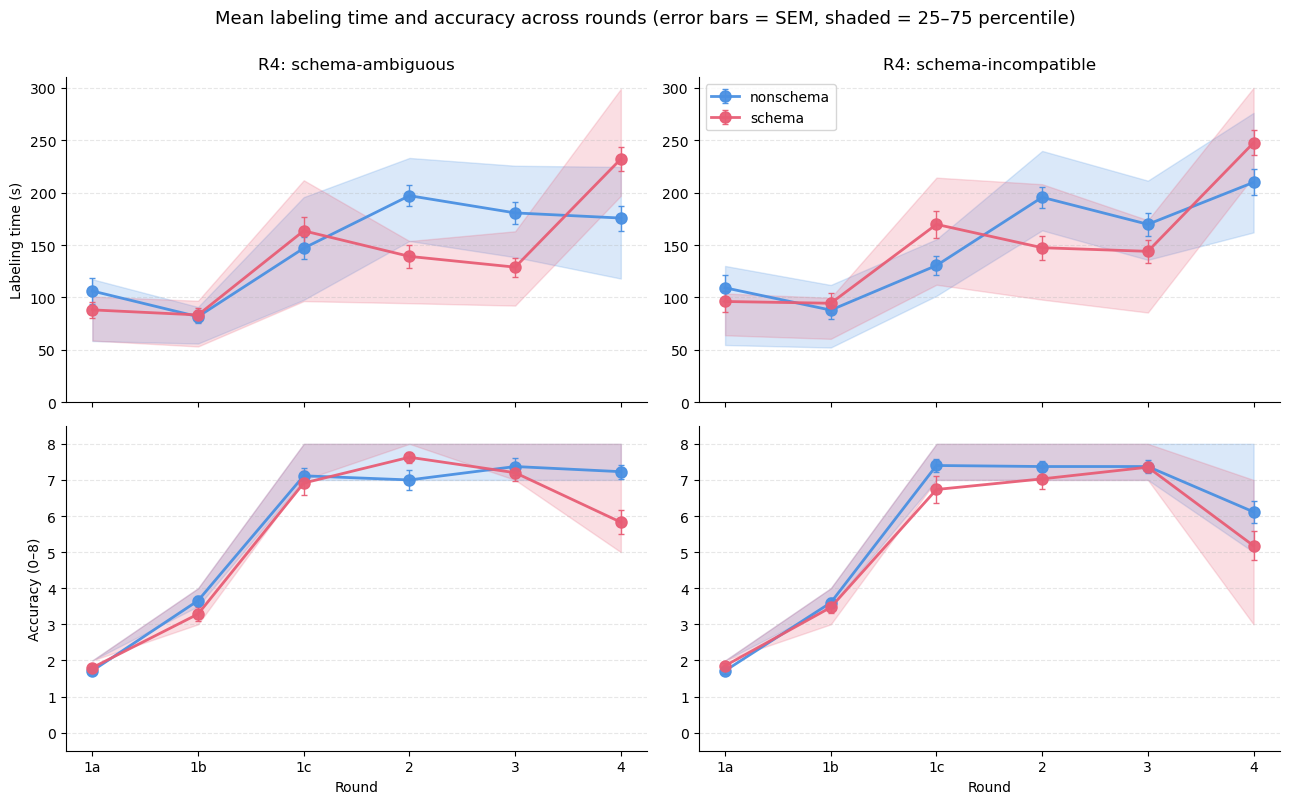

In [18]:
# [fig-all-rounds]
# Mean labeling time + accuracy across all rounds, faceted by change type.
# Layout: 2 rows (labeling time, accuracy) x 2 cols (schema-non-obvious, schema-obvious),
# parallel to the Study 1 combined figure.

time_round_cols = ["time_labeling_1a", "time_labeling_1b", "time_labeling_1c",
                   "time_labeling_2", "time_labeling_3", "time_labeling_4"]
acc_round_cols  = ["accuracy_1a", "accuracy_1b", "accuracy_1c",
                   "accuracy_2", "accuracy_3", "accuracy_4"]
round_lbls = ["1a", "1b", "1c", "2", "3", "4"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

panels = [
    # (row, cols, ylabel, ylim, is_time, summary_title_prefix)
    (0, time_round_cols, "Labeling time (s)", (0, 310), True),
    (1, acc_round_cols,  "Accuracy (0–8)",    (-0.5, 8.5), False),
]

for row, cols, ylabel, ylim, is_time in panels:
    for col_idx, ct in enumerate(["ambiguous", "incompatible"]):
        ax = axes[row, col_idx]
        for tg in ["nonschema", "schema"]:
            sub = data[(data["treatmentGroup"] == tg) & (data["changeType"] == ct)]
            if len(sub) == 0:
                continue
            means = [sub[c].mean() for c in cols]
            sems = [sub[c].sem() for c in cols]
            q25 = [sub[c].quantile(0.25) for c in cols]
            q75 = [sub[c].quantile(0.75) for c in cols]
            x = np.arange(len(cols))
            ax.fill_between(x, q25, q75, color=color_map[tg], alpha=0.2)
            ax.errorbar(x, means, yerr=sems, marker="o", color=color_map[tg],
                        linewidth=2, markersize=8, label=tg,
                        elinewidth=1, capsize=2, capthick=1, alpha=0.95)

        ax.set_xticks(range(len(round_lbls)))
        ax.set_xticklabels(round_lbls)
        if row == 1:
            ax.set_xlabel("Round")
        if col_idx == 0:
            ax.set_ylabel(ylabel)
        if row == 0:
            ax.set_title(f"R4: schema-{ct}")
        ax.set_ylim(*ylim)
        if row == 0 and col_idx == 1:
            ax.legend()
        ax.grid(axis="y", alpha=0.3, linestyle="--")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

plt.suptitle("Mean labeling time and accuracy across rounds (error bars = SEM, shaded = 25–75 percentile)",
             y=1.00, fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
# [summary-table]
# Summary of hypothesis tests. The preregistered analysis is H1 (Fisher's exact on
# schema use). The remaining rows are exploratory and were dropped from the filed prereg.

rows = []

# Try to add prereg result if available
try:
    rows.append({
        "Hypothesis": "H1 (PREREG)",
        "Test": "Fisher exact (one-tailed)",
        "Statistic": f"OR = {odds_ratio:.2f}",
        "p (one-tailed)": f"{p_fisher:.4f}",
        "Effect": f"non-obv: {a}/{a+b} schema; obv: {c}/{c+d} schema",
        "Status": "preregistered",
    })
except NameError:
    rows.append({
        "Hypothesis": "H1 (PREREG)",
        "Test": "Fisher exact (one-tailed)",
        "Statistic": "pending",
        "p (one-tailed)": "—",
        "Effect": "awaiting human coding",
        "Status": "preregistered",
    })

rows += [
    {
        "Hypothesis": "H1 acc-interaction (exploratory)",
        "Test": "Restricted permutation",
        "Statistic": f"contrast = {observed_contrast:+.3f}",
        "p (one-tailed)": f"{p_perm:.4f}",
        "Effect": f"Cliffs δ amb={cd_amb:+.2f}, inc={cd_inc:+.2f}",
        "Status": "exploratory",
    },
    {
        "Hypothesis": "H2a R4 acc (exploratory)",
        "Test": "MWU (perm)",
        "Statistic": f"U = {u_obs_2a:.1f}",
        "p (one-tailed)": f"{p_perm_2a:.4f}",
        "Effect": f"HL = {hl_2a:+.2f} [{hl_ci_2a[0]:+.2f},{hl_ci_2a[1]:+.2f}]; δ={cd_2a:+.2f}",
        "Status": "exploratory",
    },
    {
        "Hypothesis": "H2b Δacc (exploratory)",
        "Test": "MWU (perm)",
        "Statistic": f"U = {u_obs_2b:.1f}",
        "p (one-tailed)": f"{p_perm_2b:.4f}",
        "Effect": f"HL = {hl_2b:+.2f} [{hl_ci_2b[0]:+.2f},{hl_ci_2b[1]:+.2f}]; δ={cd_2b:+.2f}",
        "Status": "exploratory",
    },
    {
        "Hypothesis": "Replication amb (exploratory)",
        "Test": "MWU (perm)",
        "Statistic": f"U = {u_rep_obs:.1f}",
        "p (one-tailed)": f"{p_rep_perm:.4f}",
        "Effect": f"HL = {hl_rep:+.2f}; δ={cd_rep:+.2f}",
        "Status": "exploratory",
    },
]

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv("study_2_analysis_results.csv", index=False)

                      Hypothesis                      Test         Statistic p (one-tailed)                            Effect        Status
                     H1 (PREREG) Fisher exact (one-tailed)           pending              —             awaiting human coding preregistered
H1 acc-interaction (exploratory)    Restricted permutation contrast = -0.462         0.2441     Cliffs δ amb=-0.44, inc=-0.22   exploratory
        H2a R4 acc (exploratory)                MWU (perm)         U = 508.0         0.8537 HL = +0.00 [-2.00,+0.00]; δ=-0.15   exploratory
          H2b Δacc (exploratory)                MWU (perm)         U = 737.5         0.9590 HL = +1.00 [+0.00,+2.00]; δ=+0.24   exploratory
   Replication amb (exploratory)                MWU (perm)         U = 343.0         0.0007               HL = -1.00; δ=-0.44   exploratory
